In [2]:
#Import Libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#Dataset
data=load_breast_cancer()
X=data.data

In [8]:
#Standard Scaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [12]:
#Inertia
inertia_values=[]
k_range=(2,11)
for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
    sil_score=silhouette_score(X_scaled,kmeans.labels_)
    print("K=",k)
    print("Inertia=",kmeans.inertia_)
    print("Silhouette Score=",sil_score)

K= 2
Inertia= 11595.52660711579
Silhouette Score= 0.3433822406907781
K= 11
Inertia= 6434.48916950897
Silhouette Score= 0.13923630650180718


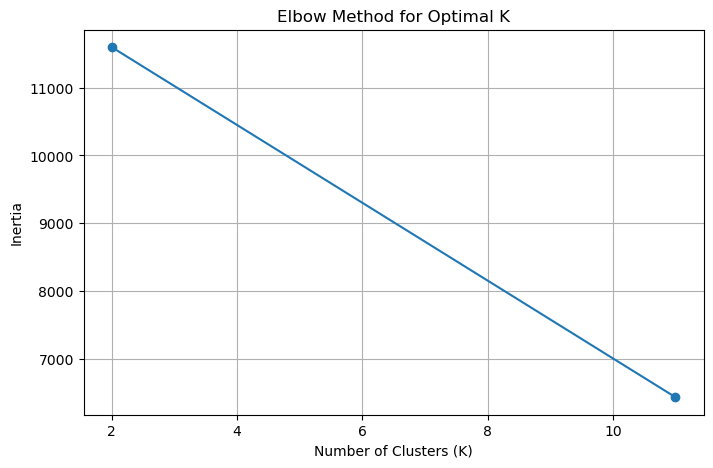

In [13]:
#Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.grid(True)
plt.show()

In [15]:
#Model
optimal_k = 2
kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)
clusters = kmeans_final.fit_predict(X_scaled)

In [16]:
#Metrics
final_inertia = kmeans_final.inertia_
final_silhouette = silhouette_score(X_scaled, clusters)

print("\nFinal Model Results")
print(f"K = {optimal_k}")
print(f"Inertia = {final_inertia:.2f}")
print(f"Silhouette Score = {final_silhouette:.4f}")


Final Model Results
K = 2
Inertia = 11595.53
Silhouette Score = 0.3434
